In [ ]:
import json
import pathlib
from pprint import pprint

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

import bonsai_loop as bl

sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]
sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]

In [2]:
import inspect

from bonsai_loop.bonsai_lib.bonsai.bonsai_dataprocessing import (  # type: ignore[import]
    loadReconstructedTreeAndData,
)
from bonsai_loop.bonsai_lib.bonsai.bonsai_helpers import (  # type: ignore[import]
    Run_Configs,
)

print(inspect.getsource(loadReconstructedTreeAndData))
print(f"{'─' * 88}")
pprint(Run_Configs.__dict__)

def loadReconstructedTreeAndData(args, tree_folder, reprocess_data=False, all_genes=False, all_ranks=True,
                                 get_cell_info=False, corrected_data=True, rel_to_results=False, no_data_needed=False,
                                 single_process=False, keep_original_data=False, calc_loglik=False, get_data=True,
                                 get_posterior_ltqs=False, otherRanksMinimalInfo=False, verbose=True,
                                 calc_posteriors=True):
    """

    :param args:
    :param tree_folder:
    :param reprocess_data:
    :param all_genes:
    :param all_ranks:
    :param get_cell_info:
    :param corrected_data:
    :param rel_to_results:
    :param no_data_needed:
    :param single_process:
    :param keep_original_data:
    :param calc_loglik:
    :param get_data:
    :param get_posterior_ltqs:
    :param otherRanksMinimalInfo:
    :param verbose:
    :param calc_posteriors: This boolean may be false, even when get_posterior_ltqs i

# Data processing

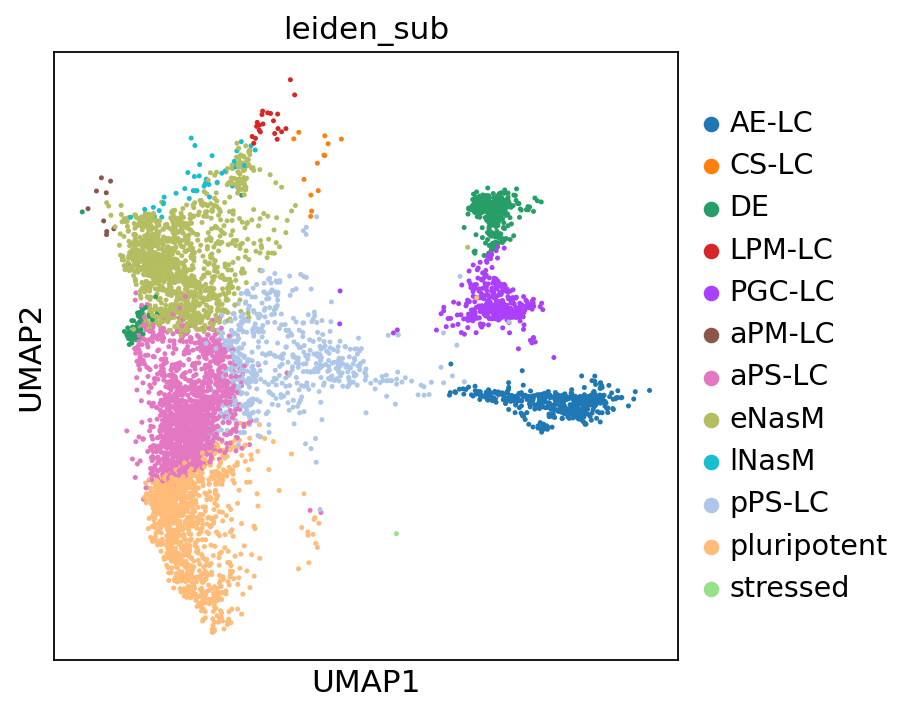

4611

In [3]:
import gc

data_path = pathlib.Path("./data")
adata = sc.read_h5ad(data_path / "adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv(data_path / "adata_timeseries_old_48h-1_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index]
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)
sc.pl.umap(adata, color=["leiden_sub"])
del meta
bonsai_gastruloid_path = data_path / "Bonsai_48h-1"
gas_bonsai_output_folder = bonsai_gastruloid_path / "final_bonsai_zscore0.75/"
gas_bonsai_config_file = bonsai_gastruloid_path / "used_run_configs.yaml"
gc.collect()

04-30 23:34:25 mp_print INFO 

Reconstructed tree loaded from: 
data/Bonsai_48h-1/final_bonsai_zscore0.75/edgeInfo.txt 
data/Bonsai_48h-1/final_bonsai_zscore0.75/vertInfo.txt
04-30 23:34:25 mp_print INFO 
Init min-dist clustering-tree
04-30 23:34:25 mp_print INFO Clustering has created 2 subtrees, 8 branches still to cut.
04-30 23:34:25 mp_print INFO Clustering has created 4 subtrees, 6 branches still to cut.
04-30 23:34:25 mp_print INFO Clustering has created 8 subtrees, 2 branches still to cut.


Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

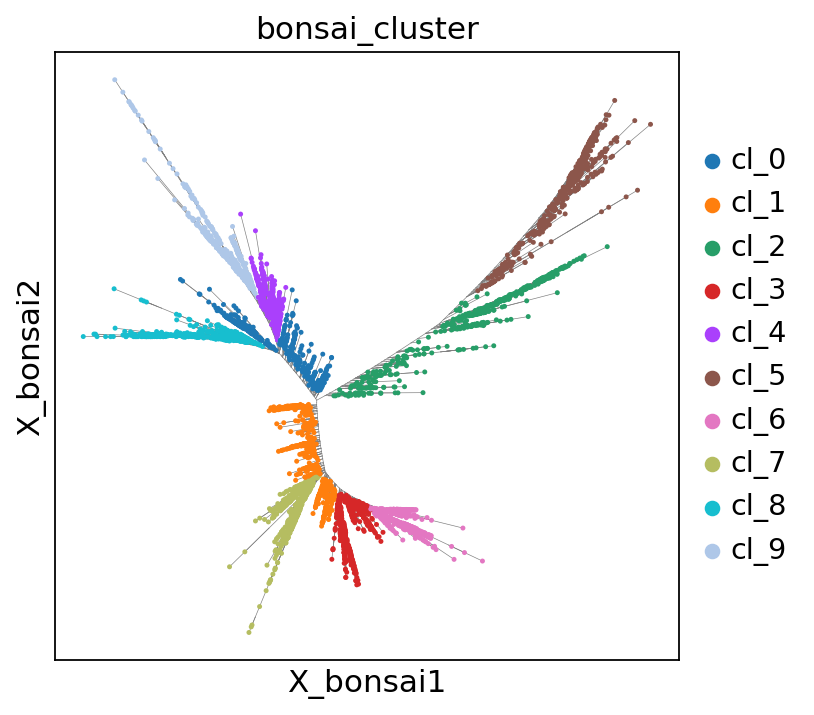

In [4]:
from bonsai_loop.bonsai_lib import bonsai_clustering  # type: ignore[import]

gas_run_configs = Run_Configs(gas_bonsai_config_file)
scData, vert_map = loadReconstructedTreeAndData(
    gas_run_configs,
    gas_bonsai_output_folder,
    rel_to_results=False,
    reprocess_data=False,
    all_ranks=False,
    get_cell_info=True,
    get_posterior_ltqs=True,
)
# compute dsLeafs for dendrogram
scData.tree.root.get_ds_info_for_ladderize()
# reroot
gas_node_id_to_vert_ind = {}
with open(gas_bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        gas_node_id_to_vert_ind[parts[2]] = int(parts[0])
new_root = "internal_1880"
scData.tree.reset_root(gas_node_id_to_vert_ind[new_root])
# clustering
f = h5py.File(bonsai_gastruloid_path / "bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]  # type: ignore[index]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]  # type: ignore[index]
cell_inds = f["tree_info/cell_inds"][:]  # type: ignore[index]
int_inds = f["tree_info/int_inds"][:]  # type: ignore[index]
metadata = json.loads(f.attrs["metadata_json"])  # type: ignore[index]
gas_cell_ids = metadata["cellIds"]  # type: ignore[index]
gas_vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])  # type: ignore[index]

cell_coords = np.zeros((len(gas_cell_ids), 2))
for vert_idx_str, cell_idx in gas_vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]  # type: ignore[index]
    else:
        cell_coords[cell_idx] = coords[vert_idx]  # type: ignore[index]
adata.obsm["X_bonsai"] = cell_coords
f.close()

with open(gas_bonsai_output_folder / "tree.nwk") as f:
    nwk_str = f.read().strip()
all_clusters, _ = bonsai_clustering.get_min_pdists_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, n_clusters=10
)
gas_clusters = all_clusters[f"annot_bnsi_cluster_n{10}"]
cluster_dict = bonsai_clustering.get_cluster_assignments({"annot": gas_clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

if "bonsai_cluster_colors" in adata.uns:
    del adata.uns["bonsai_cluster_colors"]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

# Compute node level and label

In [29]:
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["bonsai_cluster"].to_dict(),
)
bl.convergence.compute_bonsai_tree_dendrogram(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
    ladderize_by_annotated_leaves_only=True,
)

compute depth-first ordering of nodes
root node internal_1880
compute node level and label


11069it [00:00, 327456.28it/s]


In [30]:
# root node should have n_leaves = number of real cells (n=5927)
print(node_data_lookup["internal_1880"])
# a real cell (a leaf) should have n_leaves = 1
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌─────────────────────────────┬──────────────────────────────────────────────┐
│ attribute                   │ value                                        │
├─────────────────────────────┼──────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='internal_1880')             │
│ topological_level           │ 195                                          │
│ geometric_level             │ None                                         │
│ identity                    │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves                    │ 5927                                         │
│ ordering_value              │ None                                         │
│ dendrogram_coords           │ (-0.95, -0.9159482420614774)                 │
│ delta_deviation_from_parent │ None                                         │
│ other_props                 │ None                                         │
└─────────────────────────────┴─────────────────────

# Compute delta deviation scores and plot heatmap

In [55]:
# compute ordering
bl.convergence.compute_node_ordering_value(
    tree=scData.tree, node_data_lookup=node_data_lookup, metric="dendrogram"
)
ordering_node_ids = bl.convergence.compute_node_ordering(
    node_data_lookup=node_data_lookup,
    level=0,
    sort_by_identity_first=False,
    ascending=True,
)
# compute delta deviation scores for all nodes
bl.convergence.compute_delta_deviation_from_parent(
    node_data_lookup=node_data_lookup,
    reference_node_ids=ordering_node_ids,
    normalize_by_branch_length=True,
)

compute node ordering using metric dendrogram
compute deviations for 11068 branches × 5927 refs
normalize delta deviation by branch length


/home/stan/Git/bonsai-loop/src/bonsai_loop/convergence.py:773: RuntimeWarning: divide by zero encountered in divide
  delta_d /= t_parents[:, None]


In [56]:
# root node (root has no parent so no deviation score)
print(node_data_lookup["internal_1880"])
print(f"{'─' * 88}")
# a internal node
print(node_data_lookup["internal_720"])
# query some deviation scores for different reference nodes
print(node_data_lookup["internal_720"].delta_deviation_from_parent[0])
print(node_data_lookup["internal_720"].delta_deviation_from_parent[1])
print(f"{'─' * 88}")
# a real cell (a leaf)
print(node_data_lookup["AAACGAATCTGCAGCG-1_48h"])
# query some deviation scores
# can query by index
print(node_data_lookup["AAACGAATCTGCAGCG-1_48h"].delta_deviation_from_parent[50])
# or by node id
print(
    node_data_lookup["AAACGAATCTGCAGCG-1_48h"].delta_deviation_from_parent[
        "TTTGGTTTCACAACCA-1_48h"
    ]
)

┌─────────────────────────────┬──────────────────────────────────────────────┐
│ attribute                   │ value                                        │
├─────────────────────────────┼──────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='internal_1880')             │
│ topological_level           │ 195                                          │
│ geometric_level             │ None                                         │
│ identity                    │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves                    │ 5927                                         │
│ ordering_value              │ -0.9159482420614774                          │
│ dendrogram_coords           │ (-0.95, -0.9159482420614774)                 │
│ delta_deviation_from_parent │ None                                         │
│ other_props                 │ None                                         │
└─────────────────────────────┴─────────────────────

In [57]:
deviation_score_matrix = [
    [
        node_data_lookup[node_id_child].delta_deviation_from_parent[node_id_reference]
        for node_id_reference in ordering_node_ids
    ]
    for node_id_child in ordering_node_ids
]

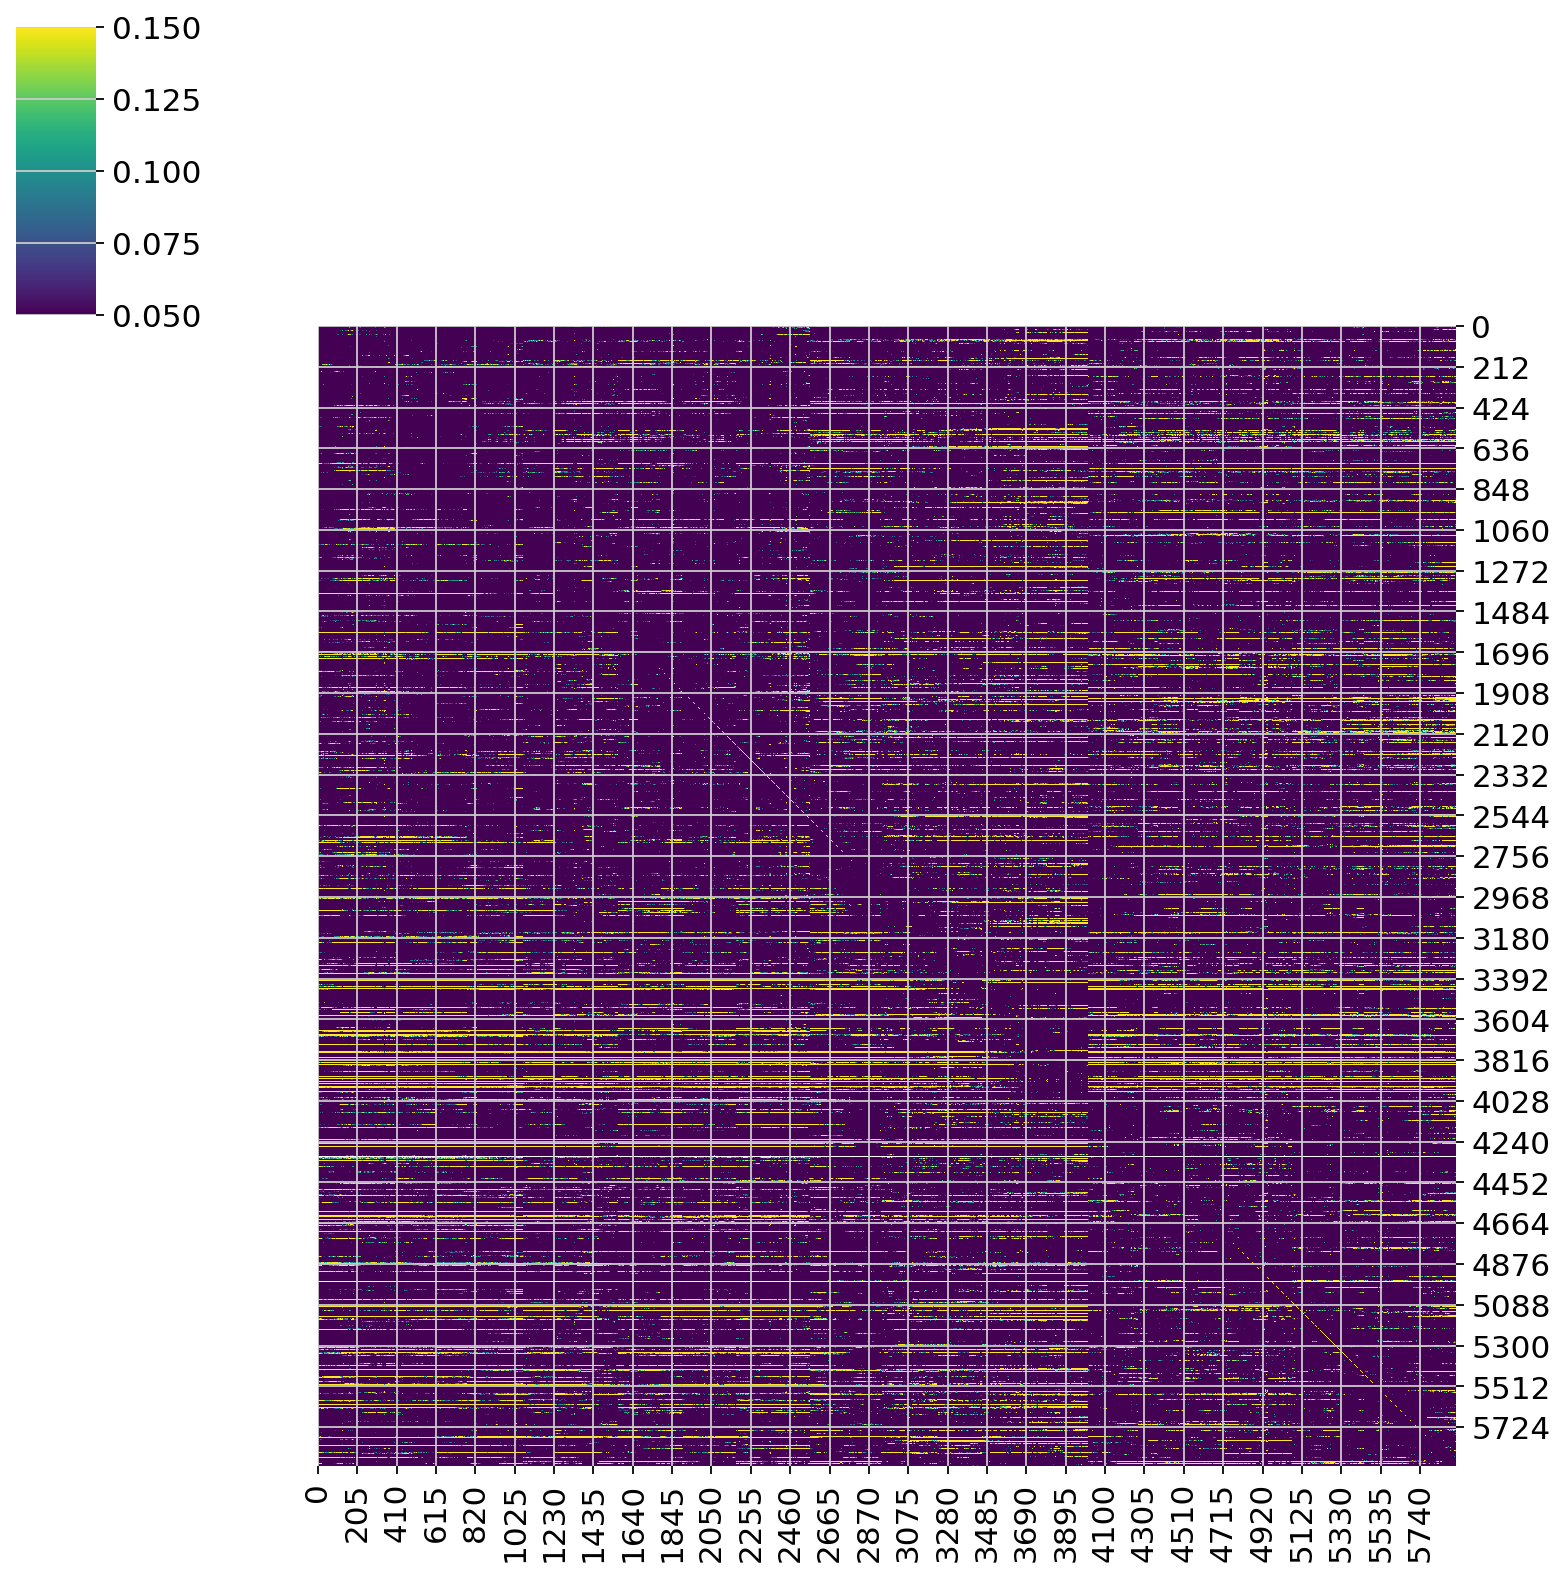

28247

In [59]:
from matplotlib.colors import Normalize

norm = Normalize(vmin=0.05, vmax=0.15)
sns.clustermap(
    deviation_score_matrix,
    row_cluster=False,
    col_cluster=False,
    cmap="viridis",
    # xticklabels=False,
    # yticklabels=False,
    norm=norm,
    figsize=(10, 10),
)
plt.show()
plt.close()
gc.collect()